In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
df = pd.read_csv('C:\\Users\\dell\\Downloads\\weather_forecast_data.csv')

In [26]:
df.head()

,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure,Rain
0,23.720338,89.592641,7.335604,50.501694,1032.378759,rain
1,27.879734,46.489704,5.952484,4.990053,992.614190,no rain
2,25.069084,83.072843,1.371992,14.855784,1007.231620,no rain
3,23.622080,74.367758,7.050551,67.255282,982.632013,rain
4,20.591370,96.858822,4.643921,47.676444,980.825142,no rain


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  2500 non-null   float64
 1   Humidity     2500 non-null   float64
 2   Wind_Speed   2500 non-null   float64
 3   Cloud_Cover  2500 non-null   float64
 4   Pressure     2500 non-null   float64
 5   Rain         2500 non-null   object 
dtypes: float64(5), object(1)
memory usage: 117.3+ KB


In [28]:
df.shape

(2500, 6)

In [29]:
df.describe()

,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure
count,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,22.581725,64.347094,9.906255,49.658104,1014.312336
std,7.326996,19.954739,5.780316,29.123104,20.196433
min,10.001842,30.005071,0.009819,0.015038,980.014486
25%,16.359398,47.339815,4.761909,23.900016,996.938630
50%,22.536448,63.920797,9.908572,49.488284,1013.433035
75%,28.976476,81.561021,14.948408,75.324140,1031.735067
max,34.995214,99.997481,19.999132,99.997795,1049.985593


In [30]:
df.isnull().sum()

Temperature    0
Humidity       0
Wind_Speed     0
Cloud_Cover    0
Pressure       0
Rain           0
dtype: int64

## correlation
- we can encode the output feature and we can check the correlation.
- we can also use the RandomForestClassifier to the importances given to each feature.

### we can explore both of them.

- encoding the output variable.

In [31]:
x=df['Rain'].map({'rain':1,'no rain':0})

In [32]:
x

0       1
1       0
2       0
3       1
4       0
       ..
2495    0
2496    0
2497    0
2498    0
2499    0
Name: Rain, Length: 2500, dtype: int64

In [33]:
df= pd.concat([df,x],axis=1)

In [34]:
df.head()

,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure,Rain,Rain
0,23.720338,89.592641,7.335604,50.501694,1032.378759,rain,1
1,27.879734,46.489704,5.952484,4.990053,992.614190,no rain,0
2,25.069084,83.072843,1.371992,14.855784,1007.231620,no rain,0
3,23.622080,74.367758,7.050551,67.255282,982.632013,rain,1
4,20.591370,96.858822,4.643921,47.676444,980.825142,no rain,0


In [35]:
corr=df.select_dtypes(include=np.number).corr()
corr

,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure,Rain
Temperature,1.000000,-0.014119,-0.004957,0.006632,-0.007489,-0.265882
Humidity,-0.014119,1.000000,0.003816,0.007244,-0.032089,0.382464
Wind_Speed,-0.004957,0.003816,1.000000,-0.000405,0.018772,-0.001389
Cloud_Cover,0.006632,0.007244,-0.000405,1.000000,0.023100,0.326216
Pressure,-0.007489,-0.032089,0.018772,0.023100,1.000000,0.008273
Rain,-0.265882,0.382464,-0.001389,0.326216,0.008273,1.000000


<Axes: >

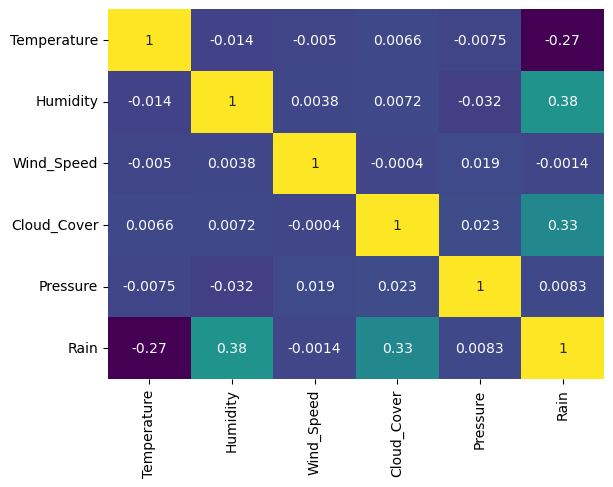

In [36]:
sns.heatmap(corr,cmap='viridis',cbar=False,annot=True)

## Observations

- Temperature vs Rain → -0.27
-- Negative correlation: lower temperatures are associated with higher chances of rain.

- Humidity vs Rain → 0.38
-- Moderate positive correlation: higher humidity strongly contributes to rain.

- Cloud Cover vs Rain → 0.33
-- Moderate positive correlation: more cloud cover increases the likelihood of rain.

- Wind Speed vs Rain → -0.0014
-- Almost no correlation: wind speed has negligible effect on rainfall in this dataset.

- Pressure vs Rain → 0.0083
-- Very weak correlation: atmospheric pressure doesn’t show strong influence here.

In [37]:
df.head()

,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure,Rain,Rain
0,23.720338,89.592641,7.335604,50.501694,1032.378759,rain,1
1,27.879734,46.489704,5.952484,4.990053,992.614190,no rain,0
2,25.069084,83.072843,1.371992,14.855784,1007.231620,no rain,0
3,23.622080,74.367758,7.050551,67.255282,982.632013,rain,1
4,20.591370,96.858822,4.643921,47.676444,980.825142,no rain,0


In [38]:
df['Rain']

,Rain,Rain
0,rain,1
1,no rain,0
2,no rain,0
3,rain,1
4,no rain,0
...,...,...
2495,no rain,0
2496,no rain,0
2497,no rain,0
2498,no rain,0


In [39]:
# Keep only the categorical Rain column
df = df.loc[:, ~((df.columns == 'Rain') & (df.dtypes != 'object'))]

In [40]:
df.head()

,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure,Rain
0,23.720338,89.592641,7.335604,50.501694,1032.378759,rain
1,27.879734,46.489704,5.952484,4.990053,992.614190,no rain
2,25.069084,83.072843,1.371992,14.855784,1007.231620,no rain
3,23.622080,74.367758,7.050551,67.255282,982.632013,rain
4,20.591370,96.858822,4.643921,47.676444,980.825142,no rain


# Univariate Analysis

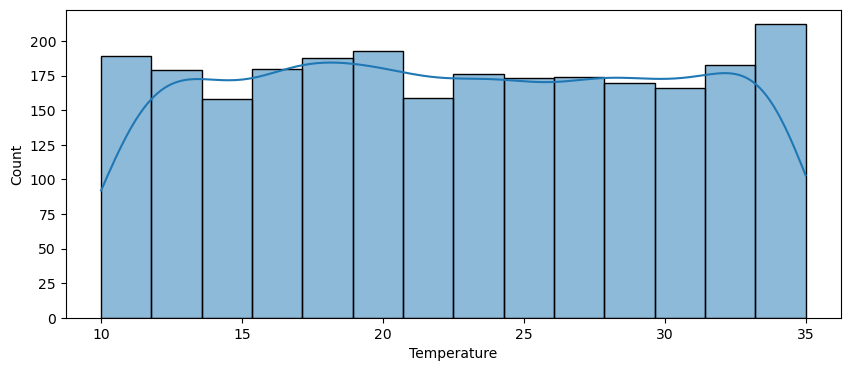

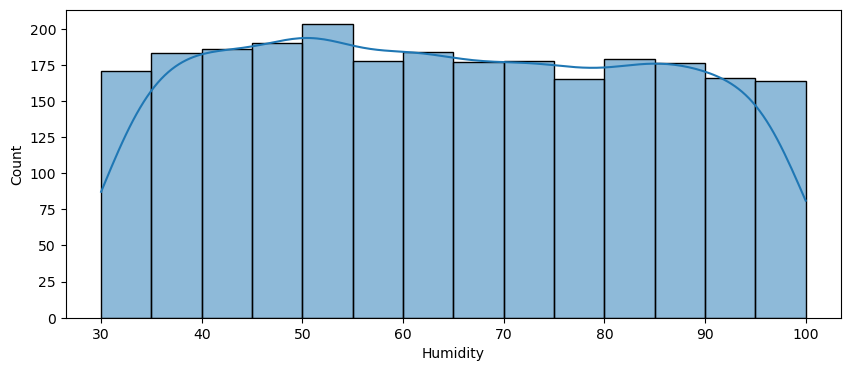

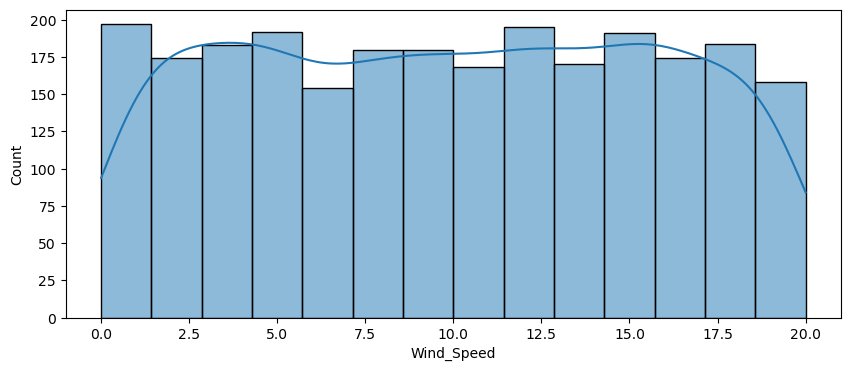

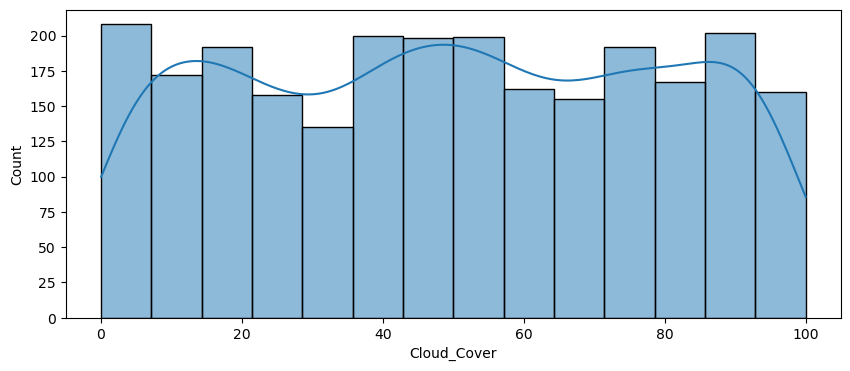

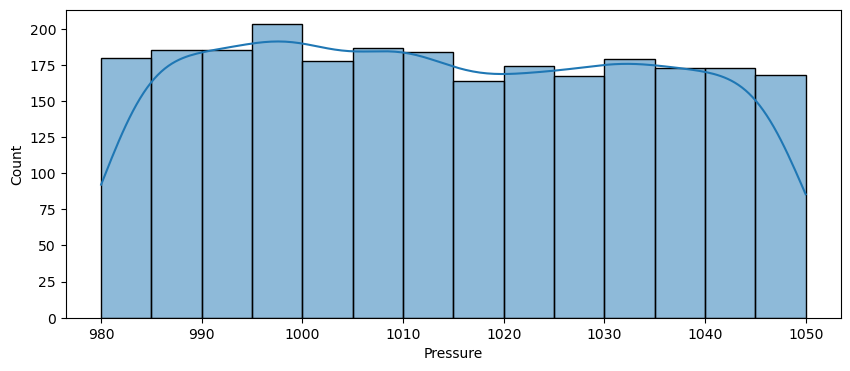

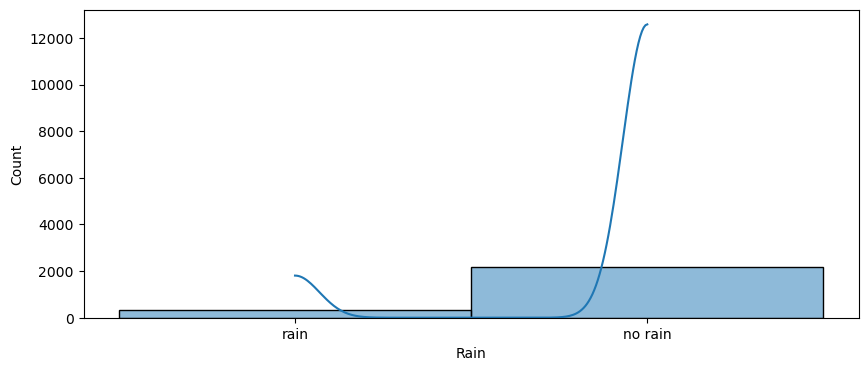

In [48]:
for col in df.columns:
    plt.figure(figsize=(10,4))
    sns.histplot(df,x=col,kde=True)
    plt.show()

## Bivariate Analysis

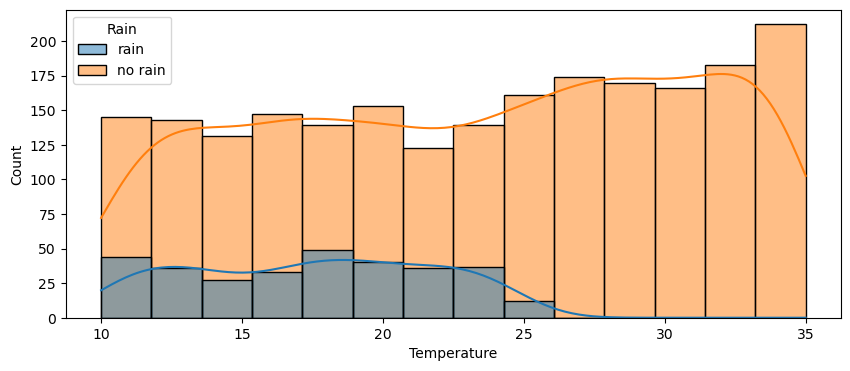

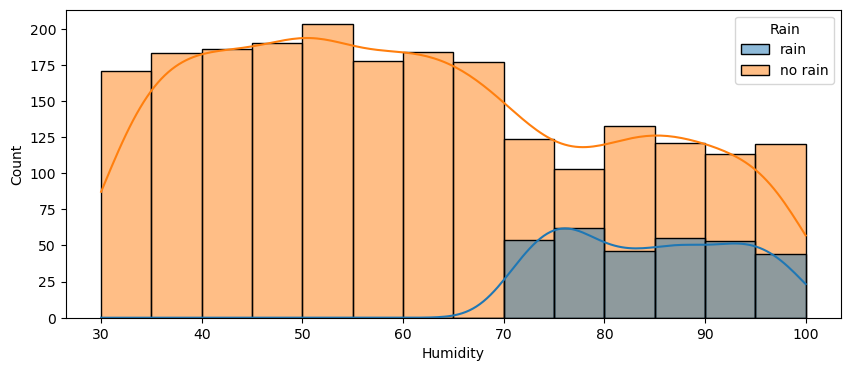

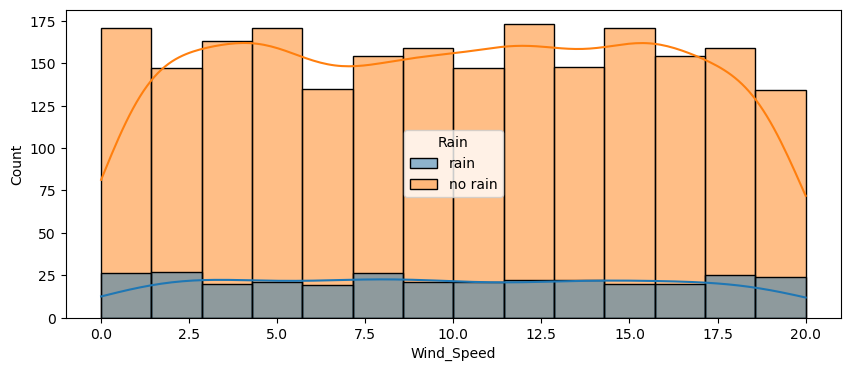

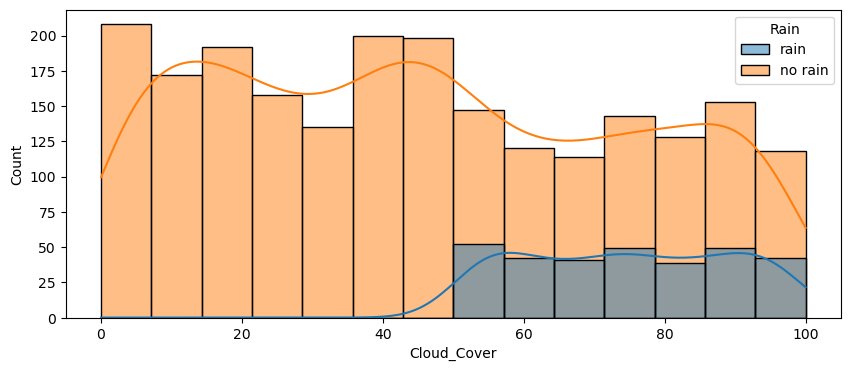

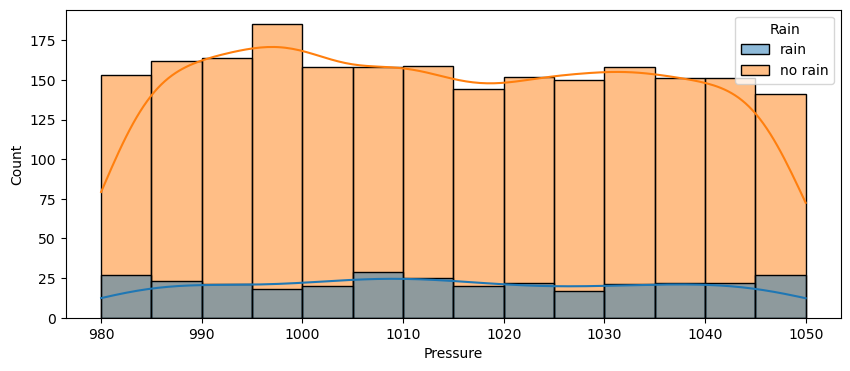

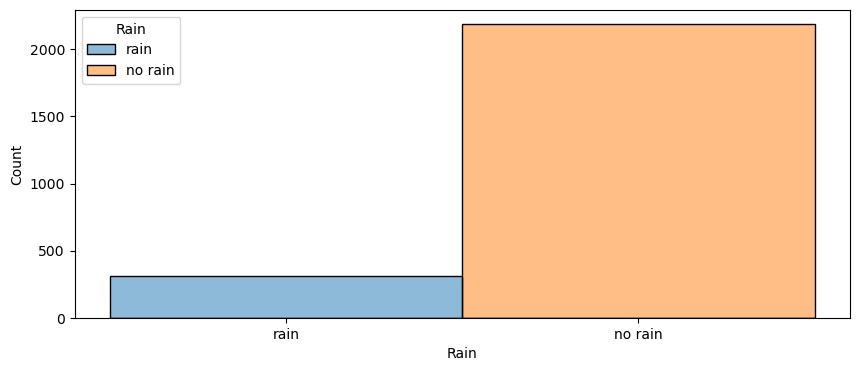

In [49]:
for col in df.columns:
    plt.figure(figsize=(10,4))
    sns.histplot(df,x=col,kde=True,hue='Rain')
    plt.show()

## Feature Engineering

In [50]:
df.Rain.value_counts()

Rain
no rain    2186
rain        314
Name: count, dtype: int64

## Observation
- it is an imbalanced Dataset

In [55]:
# we can use the SMOTE

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [54]:
X=df.drop('Rain',axis=1)
y=df['Rain']

In [56]:
scaler = MinMaxScaler().fit(X)

In [58]:
X_scaled = scaler.transform(X)

In [65]:
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df

,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure
0,0.548885,0.851343,0.366485,0.504954,0.748370
1,0.715305,0.235520,0.297292,0.049759,0.180070
2,0.602850,0.758193,0.068145,0.148433,0.388977
3,0.544954,0.633821,0.352225,0.672518,0.037409
4,0.423693,0.955157,0.231829,0.476696,0.011586
...,...,...,...,...,...
2495,0.471715,0.218107,0.590184,0.550391,0.538389
2496,0.702452,0.235407,0.544045,0.397069,0.408404
2497,0.724449,0.197337,0.144443,0.758410,0.273037
2498,0.191548,0.398658,0.118308,0.023641,0.950212


In [66]:
X_train,X_test,y_train,y_test  = train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)

- The stratify=y parameter in train_test_split is used to make sure the class distribution (imbalanced in your case: no rain = 2186, rain = 314) is preserved in both the training and test sets.

In [69]:
smote =SMOTE(random_state=42)
X_train_res,y_train_res = smote.fit_resample(X_train,y_train)
print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_res.value_counts())

Before SMOTE: Rain
no rain    1530
rain        220
Name: count, dtype: int64
After SMOTE: Rain
no rain    1530
rain       1530
Name: count, dtype: int64


#### The correct workflow is:
- Apply `SMOTE` only on the `training data`.
- Keep the `test data untouched` to evaluate realistically.

In [70]:
X_train_res.shape

(3060, 5)

In [71]:
y_train_res.shape

(3060,)

In [73]:
X_test.shape

(750, 5)

In [75]:
y_test.shape

(750,)

## Model Evalution and Prediction

In [76]:
from sklearn.linear_model import LogisticRegression

In [112]:
model = LogisticRegression().fit(X_train_res,y_train_res)

In [113]:
preds = model.predict(X_test)

In [114]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [115]:
acc=accuracy_score(y_test,preds)
cf=confusion_matrix(y_test,preds)
clr = classification_report(y_test,preds)
acc

0.8933333333333333

In [116]:
cf

array([[585,  71],
       [  9,  85]], dtype=int64)

In [117]:
print(clr)

              precision    recall  f1-score   support

     no rain       0.98      0.89      0.94       656
        rain       0.54      0.90      0.68        94

    accuracy                           0.89       750
   macro avg       0.76      0.90      0.81       750
weighted avg       0.93      0.89      0.90       750



In [135]:
from sklearn.tree import DecisionTreeClassifier

In [136]:
model1 = DecisionTreeClassifier(max_depth=5,random_state=42).fit(X_train_res,y_train_res)

In [137]:
preds = model1.predict(X_test)

In [138]:
acc_s=accuracy_score(y_test,preds)
cf_m=confusion_matrix(y_test,preds)
cl_r = classification_report(y_test,preds)
acc_s

0.9986666666666667

In [139]:
cf_m

array([[655,   1],
       [  0,  94]], dtype=int64)

In [140]:
print(cl_r)

              precision    recall  f1-score   support

     no rain       1.00      1.00      1.00       656
        rain       0.99      1.00      0.99        94

    accuracy                           1.00       750
   macro avg       0.99      1.00      1.00       750
weighted avg       1.00      1.00      1.00       750



In [133]:
import pandas as pd

# create hashes of rows to easily compare
train_hashes = pd.util.hash_pandas_object(pd.DataFrame(X_train)).values
test_hashes  = pd.util.hash_pandas_object(pd.DataFrame(X_test)).values

# intersection
leak_idx = set(train_hashes) & set(test_hashes)
print(f"Number of overlapping rows between train and test: {len(leak_idx)}")


Number of overlapping rows between train and test: 0


In [134]:
from sklearn.feature_selection import mutual_info_classif
import numpy as np

mi = mutual_info_classif(X_train, y_train)
for col, score in zip(X_train.columns, mi):
    print(col, score)


Temperature 0.06451754553977662
Humidity 0.12159632063336345
Wind_Speed 0.0
Cloud_Cover 0.08436826302975509
Pressure 0.0
